# Day 4 - Matplotlib & Seaborn: Visualising the Titanic Dataset

In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load clean dataset from day 3
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

In [5]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [6]:
#Quick clean
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
#df = df.drop(columns=['Cabin'])
df['Sex_encoded'] = df['Sex'].map({'male':0, 'female':1})
df['FamilySize'] = df['Parch'] + df['SibSp'] + 1
df['IsAlone'] = df.apply(lambda row: 1 if (row['SibSp'] + row['Parch'])==0 else 0, axis=1)
df['Title'] = df['Name'].str.split(', ').str[1].str.split('.').str[0]
common_titles = ['Mr', 'Mrs', 'Miss', 'Master']
df['TitleGroup'] = df['Title'].apply(lambda x: x if x in common_titles else 'Others')

## Part 1 - Matplotlib Basics

In [12]:
# Every matplotlib plot follows this pattern:
# 1. Create figure and axes
# 2. Plot on the axes
# 3. Add labels
# 4. Show

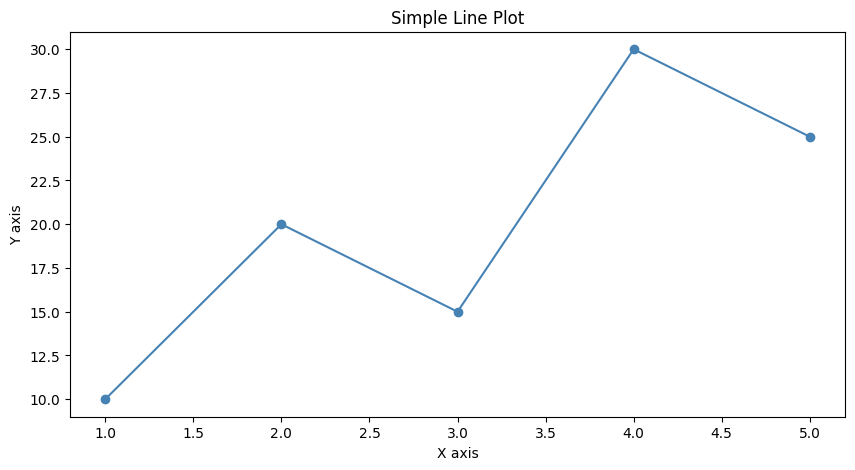

In [7]:
#Basic line plot

fig, ax = plt.subplots(figsize=(10,5))
ax.plot([1,2,3,4,5], [10,20,15,30,25], marker='o', color='steelblue')
ax.set_title('Simple Line Plot')
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
plt.show()

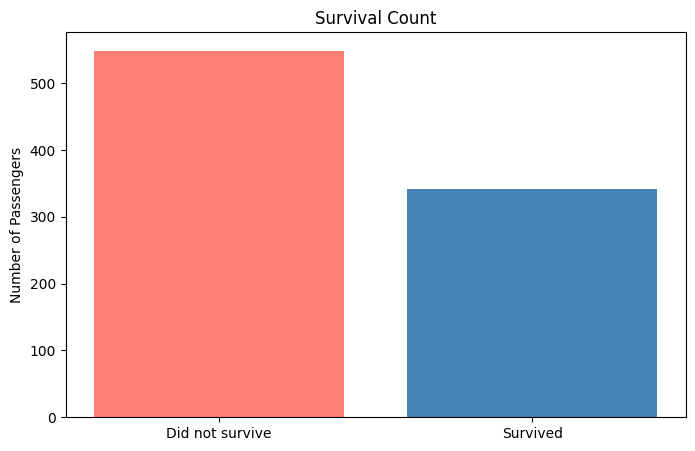

In [8]:
#Bar chart - survival count
fig, ax = plt.subplots(figsize=(8,5))
survival_counts = df['Survived'].value_counts()
ax.bar(['Did not survive', 'Survived'], survival_counts.values, color=['salmon', 'steelblue'])
ax.set_title('Survival Count')
ax.set_ylabel('Number of Passengers')
plt.show()

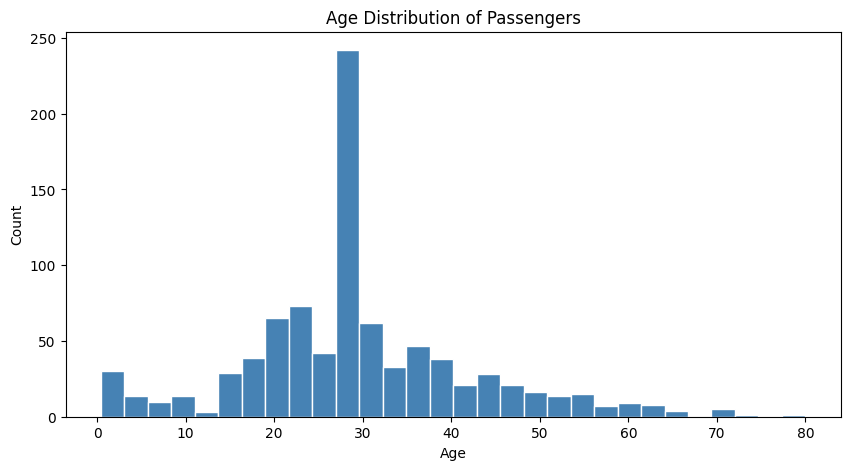

In [9]:
#Histogram - age distribution
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(df['Age'], bins=30, color='steelblue', edgecolor='white')
ax.set_title('Age Distribution of Passengers')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
plt.show()

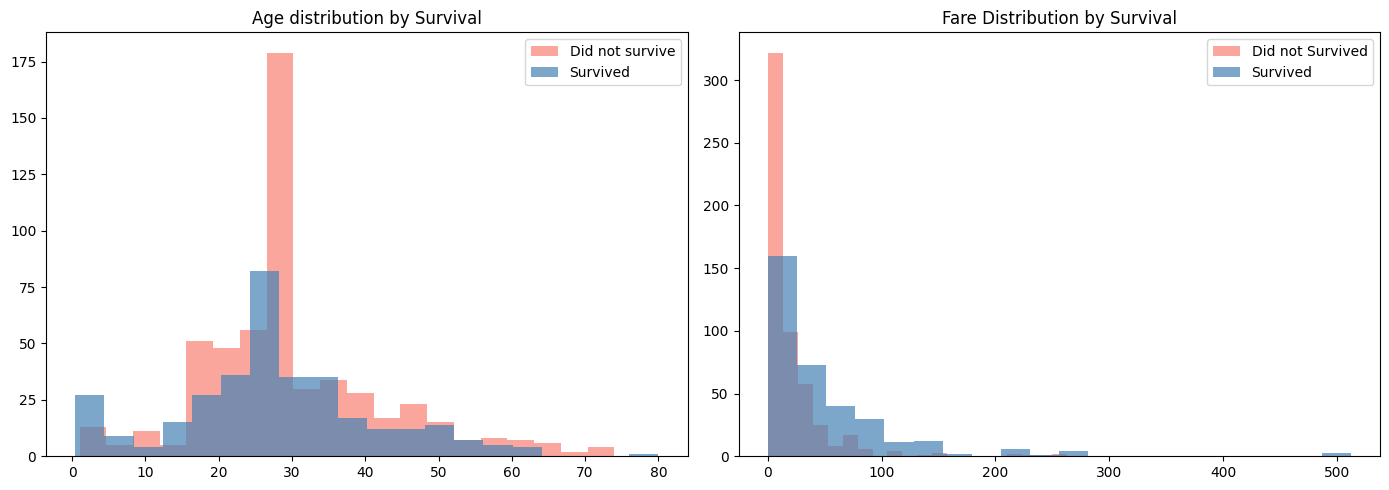

In [10]:
#Multiple plots side by side - subplots
fig, axes = plt.subplots(1,2, figsize=(14,5))

axes[0].hist(df[df['Survived']==0]['Age'], bins=20, color='salmon', alpha=0.7, label='Did not survive')
axes[0].hist(df[df['Survived']==1]['Age'], bins=20, color='steelblue', alpha=0.7, label='Survived')
axes[0].set_title('Age distribution by Survival')
axes[0].legend()

axes[1].hist(df[df['Survived']==0]['Fare'], bins=20, color='salmon', alpha=0.7, label='Did not Survived')
axes[1].hist(df[df['Survived']==1]['Fare'], bins=20, color='steelblue', alpha=0.7, label='Survived')
axes[1].set_title('Fare Distribution by Survival')
axes[1].legend()

plt.tight_layout()
plt.show()

## Part 2 - Seaborn

In [11]:
#Set style once at the top - makes everything look better
sns.set_style('whitegrid')

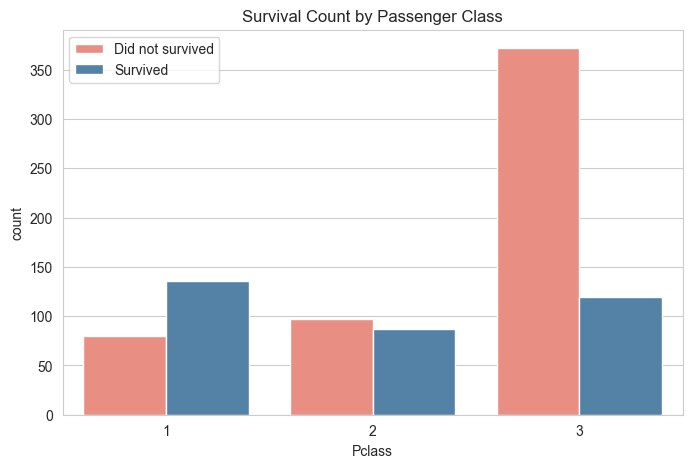

In [12]:
#Countplot - categorical frequencies
fig, ax = plt.subplots(figsize=(8,5))
sns.countplot(data=df, x='Pclass', hue='Survived', palette=['Salmon', 'steelblue'], ax=ax)
ax.set_title('Survival Count by Passenger Class')
ax.legend(labels=['Did not survived', 'Survived'])
plt.show()

C:\Users\mohiu\AppData\Local\Temp\ipykernel_24204\665738457.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='TitleGroup', y='Survived', palette='Blues_d', ax=ax)


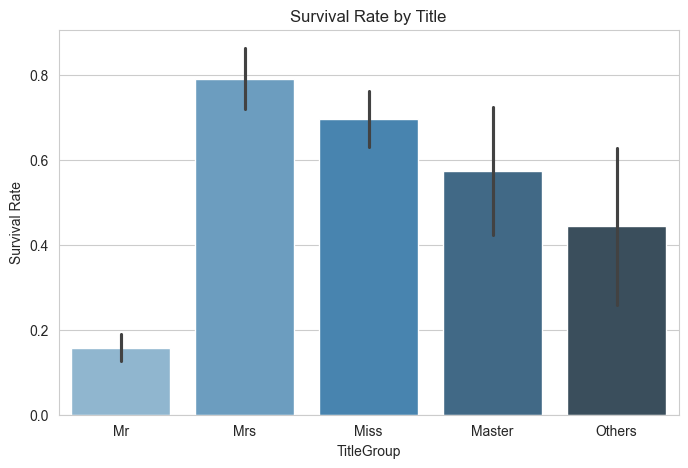

In [14]:
#Barplot - mean of numeric by category (with confidence intervals)
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(data=df, x='TitleGroup', y='Survived', palette='Blues_d', ax=ax)
ax.set_title('Survival Rate by Title')
ax.set_ylabel('Survival Rate')
plt.show()

C:\Users\mohiu\AppData\Local\Temp\ipykernel_24204\3421643000.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pclass', y='Age', palette='Set2', ax=ax)


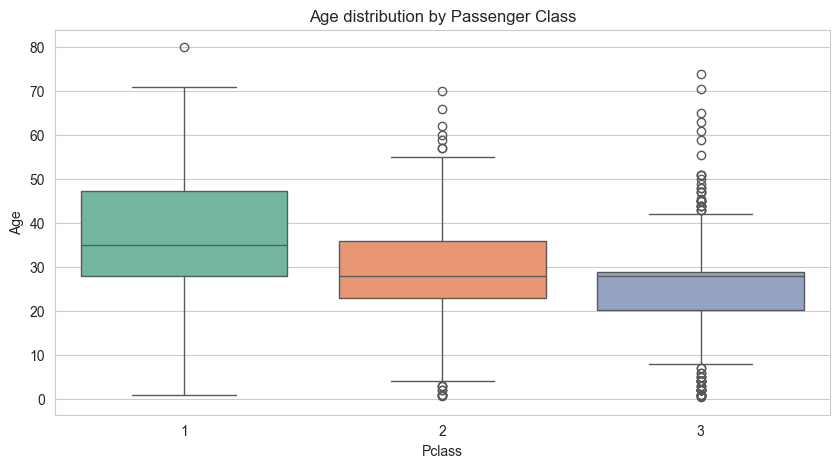

In [15]:
#Boxplot - distributon + outliers
fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(data=df, x='Pclass', y='Age', palette='Set2', ax=ax)
ax.set_title('Age distribution by Passenger Class')
plt.show()

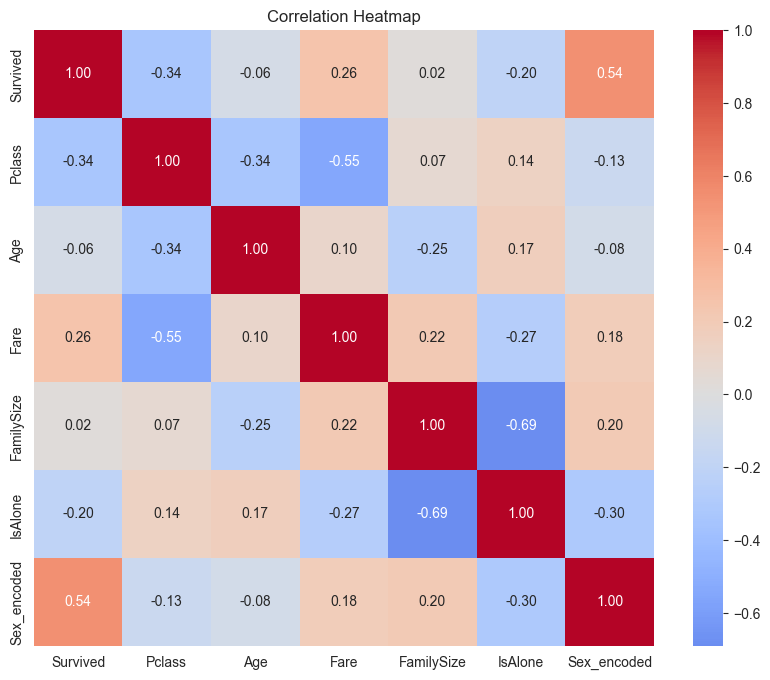

In [16]:
#Heatmap - correlation between numeric columns
fig, ax= plt.subplots(figsize=(10,8))
numeric_cols = ['Survived', 'Pclass', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Sex_encoded']
correlation = df[numeric_cols].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap')
plt.show()

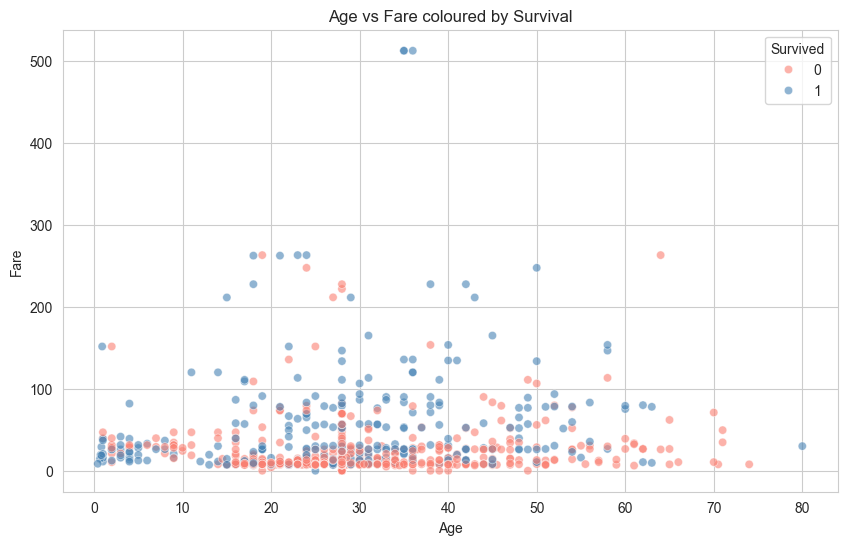

In [18]:
#Scatterplot with colour encoding
fig, ax = plt.subplots(figsize=(10,6))
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived', palette=['salmon','steelblue'], alpha=0.6, ax=ax)
ax.set_title('Age vs Fare coloured by Survival')
plt.show()

## Part 3 - Exercises

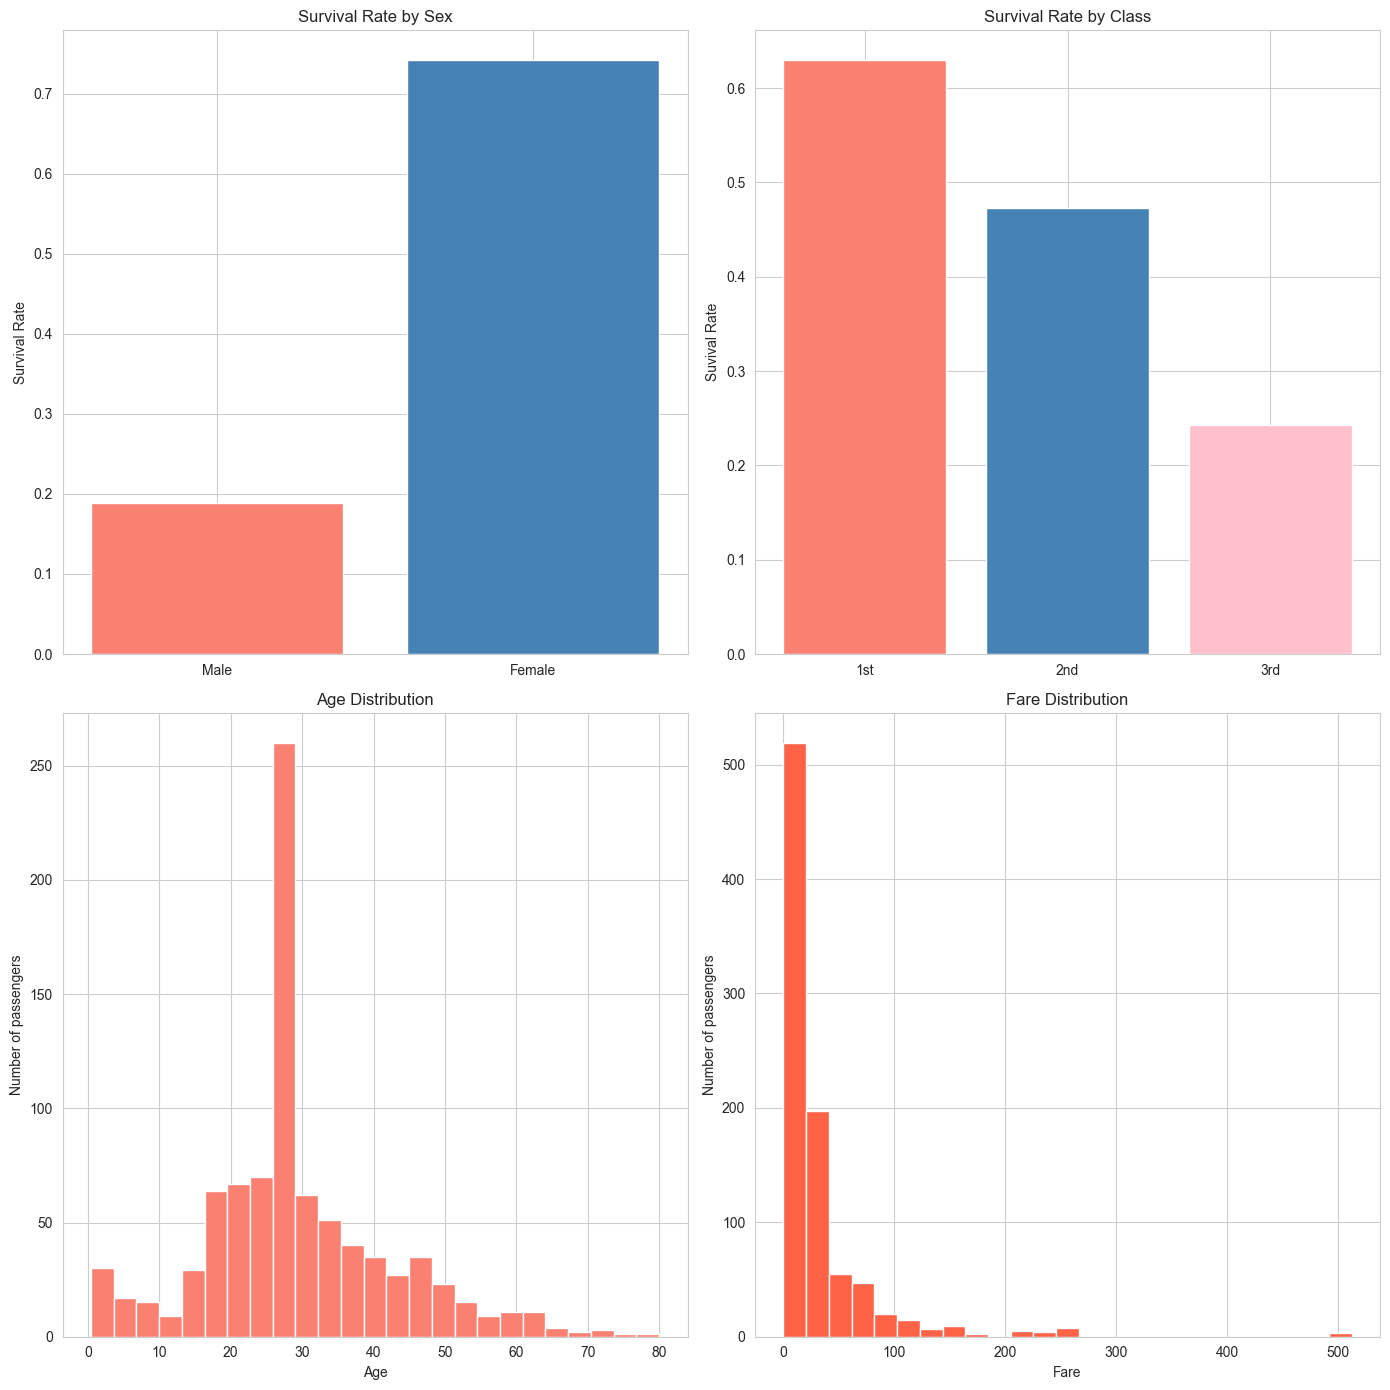

In [36]:
# Exercise 1
# Create a figure with 4 subplots (2x2 grid)
# Top left: survival rate by Sex (barplot)
# Top right: survival rate by Pclass (barplot)
# Bottom left: age distribution (histogram, 25 bins)
# Bottom right: fare distribution (histogram, 25 bins)
# Add a title to each subplot
# Use plt.tight_layout() at the end

fig, axes = plt.subplots(2,2, figsize=(14,14))

survival_rate_sex = df.groupby('Sex_encoded')['Survived'].mean()
axes[0,0].bar(['Male', 'Female'], survival_rate_sex.values, color=['salmon', 'steelblue'])
axes[0,0].set_title('Survival Rate by Sex')
axes[0,0].set_ylabel('Survival Rate')


survival_rate_cls = df.groupby('Pclass')['Survived'].mean()
axes[0,1].bar(['1st','2nd','3rd'], survival_rate_cls.values, color=['salmon','steelblue','pink'])
axes[0,1].set_title('Survival Rate by Class')
axes[0,1].set_ylabel('Suvival Rate')


axes[1,0].hist(df['Age'], bins=25, color='salmon')
axes[1,0].set_title('Age Distribution')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Number of passengers')


axes[1,1].hist(df['Fare'], bins=25, color='tomato')
axes[1,1].set_title('Fare Distribution')
axes[1,1].set_xlabel('Fare')
axes[1,1].set_ylabel('Number of passengers')

plt.tight_layout()
plt.show()

Exercise 2-4 Failed to solve.

Sex       female      male
Pclass                    
1       0.968085  0.368852
2       0.921053  0.157407
3       0.500000  0.135447


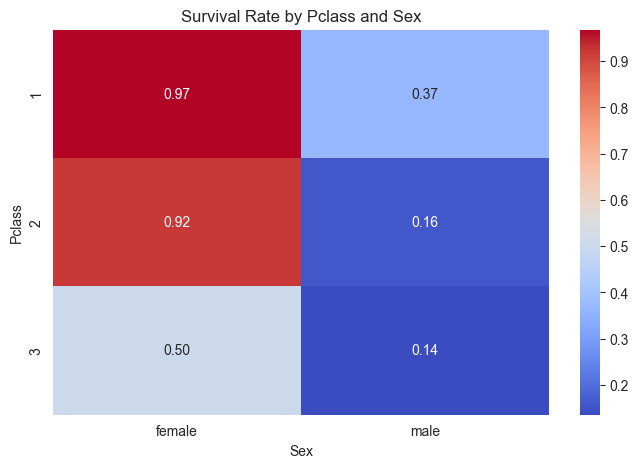

In [40]:
# Exercise 2
# Create a heatmap showing survival rate for every
# combination of Pclass and Sex
# Hint: df.groupby(['Pclass','Sex'])['Survived'].mean().unstack()
# Then pass that to sns.heatmap()
# Add annot=True so the numbers show

#Answer:

# Step 1 - build the survival rate for each pclass + sex combination
pivot = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()
print(pivot)

# Step 2 - pass that table to heatmap
fig, ax = plt.subplots(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Survival Rate by Pclass and Sex')
plt.show()

C:\Users\mohiu\AppData\Local\Temp\ipykernel_24204\40796479.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='FamilySize', y='Survived', palette='Blues_d', ax=ax)


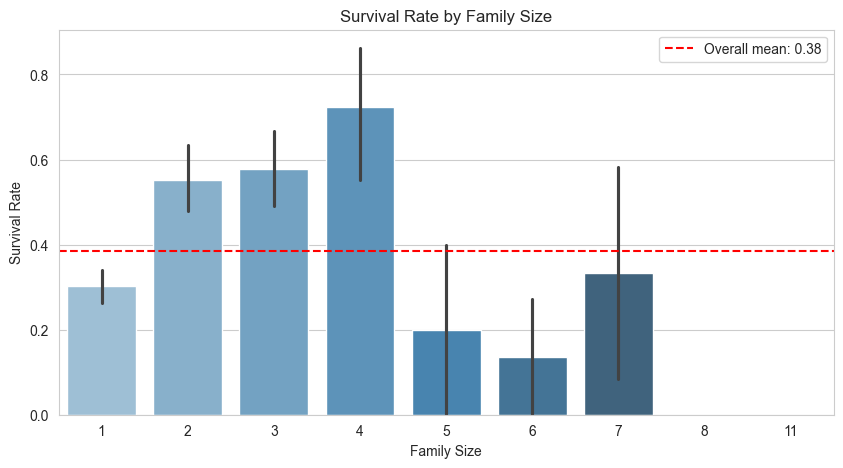

Best survival rate: Family size of 4


In [42]:
# Exercise 3
# Plot survival rate by FamilySize using a barplot
# What family size had the best survival rate?
# Add a horizontal line at the overall mean survival rate
# Hint: ax.axhline(df['Survived'].mean(), color='red', linestyle='--', label='Overall mean')

#Answer:

#Step 1 - plot survival rate by FamilySize
fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(data=df, x='FamilySize', y='Survived', palette='Blues_d', ax=ax)

#Step 2 - add the overall mean as a reference line
overall_mean = df['Survived'].mean()
ax.axhline(overall_mean, color='red', linestyle='--', label=f'Overall mean: {overall_mean:.2f}')

#Step 3 - labels and legends
ax.set_title('Survival Rate by Family Size')
ax.set_xlabel('Family Size')
ax.set_ylabel('Survival Rate')
ax.legend()
plt.show()

# What family size had the best survival rate?
best = df.groupby('FamilySize')['Survived'].mean().idxmax()
print(f"Best survival rate: Family size of {best}")

C:\Users\mohiu\AppData\Local\Temp\ipykernel_24204\3712834243.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Sex', y='Survived', palette=['salmon', 'steelblue'], ax=axes[0])
C:\Users\mohiu\AppData\Local\Temp\ipykernel_24204\3712834243.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Pclass', y='Survived', palette='Blues_d', ax=axes[1])


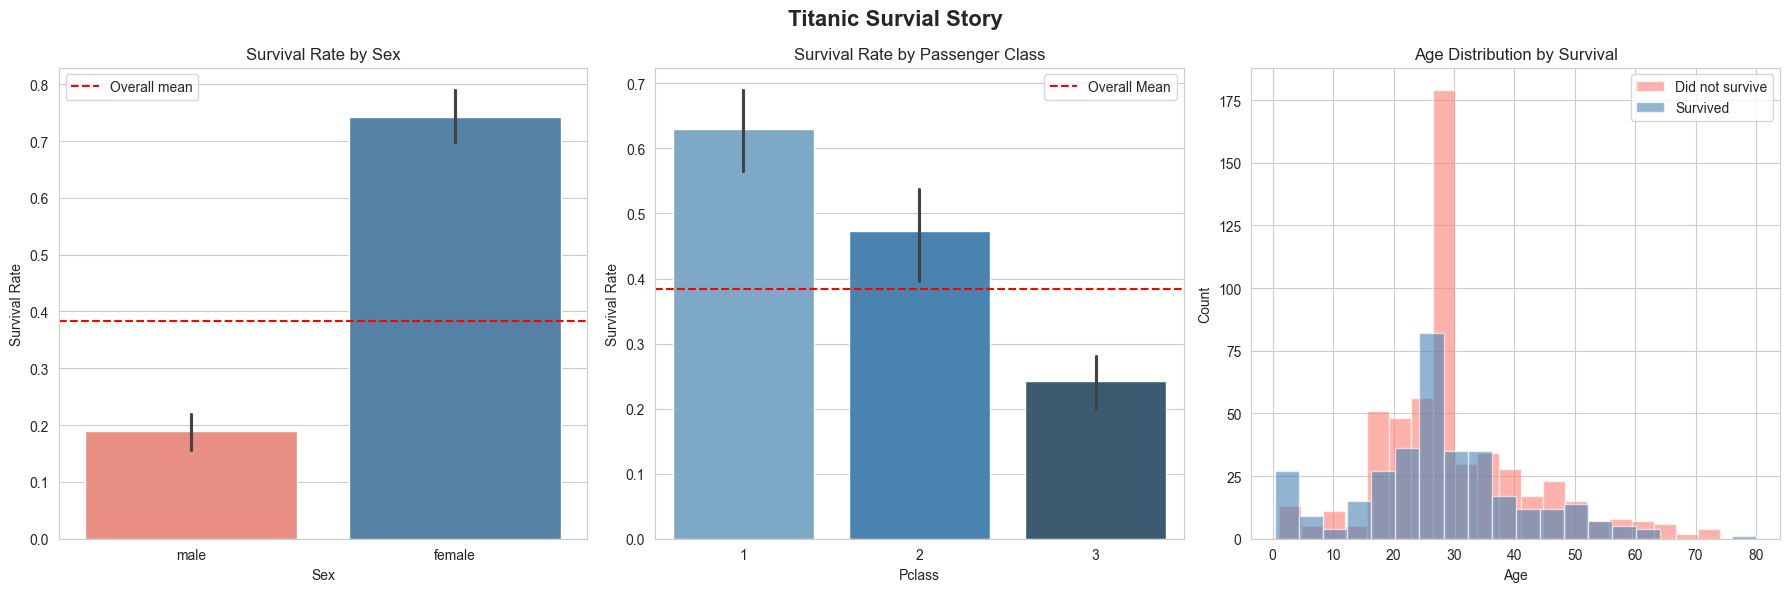

In [50]:
# Exercise 4 (stretch)
# Create a single figure that tells the full Titanic survival story
# Include at least 3 of the most interesting insights you found
# across Days 2, 3, and 4
# Proper titles, labels, and a main figure title using fig.suptitle()
# Save it as 'titanic_story.png' using plt.savefig('titanic_story.png', dpi=150)
# This goes in your GitHub README as your first data visualisation

#Answer:

fig, axes = plt.subplots(1,3, figsize=(18,6))

fig.suptitle('Titanic Survial Story', fontsize=16, fontweight='bold')

#Insight 1 - survival by sex
sns.barplot(data=df, x='Sex', y='Survived', palette=['salmon', 'steelblue'], ax=axes[0])
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate')
axes[0].axhline(df['Survived'].mean(), color='Red', linestyle='--', label='Overall mean')
axes[0].legend()

#Insight 2 - survival by class
sns.barplot(data=df, x='Pclass', y='Survived', palette='Blues_d', ax=axes[1])
axes[1].set_title('Survival Rate by Passenger Class')
axes[1].set_ylabel('Survival Rate')
axes[1].axhline(df['Survived'].mean(), color='red', linestyle='--', label='Overall Mean')
axes[1].legend()


# Insight 3 — age distribution by survival
axes[2].hist(df[df['Survived']==0]['Age'], bins=20, alpha=0.6, color='salmon', label='Did not survive')
axes[2].hist(df[df['Survived']==1]['Age'], bins=20, alpha=0.6, color='steelblue', label='Survived')
axes[2].set_title('Age Distribution by Survival')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.savefig('titanic_story.png', dpi=150)
plt.show()